Python notebook to calculate various statistics between two annotations.

## Data and Libraries

In [1]:
from dataset_processing import cwed4eta_process_json_file, convert_to_token_spans, CLIRENER_LABELS_V1
import numpy as np
import krippendorff
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Load the data:

In [2]:
data_1 = convert_to_token_spans(cwed4eta_process_json_file("DATA/project-30-at-2025-11-14-12-19-2a7464a5.json"))
data_2 = convert_to_token_spans(cwed4eta_process_json_file("RESULTS/ANNOTATORS/5/part2.json", [9]))

### Helper Functions

In [4]:


def generate_consistent_label_map(entity_types):
    """
    Generates a consistent BIO label map from a set of raw entity types.
    Ensures 'O' is included and indices are deterministic (sorted).
    """
    # 1. Always start with 'O'
    bio_labels = ["O"]
    
    # 2. Create B- and I- tags for every entity type
    sorted_types = sorted(list(entity_types))
    for label in sorted_types:
        bio_labels.append(f"B-{label}")
        bio_labels.append(f"I-{label}")
        
    # 3. Create the dictionary: {'O': 0, 'B-Asset': 1, ...}
    # We sort the final list to ensure 'O' and the rest are in a predictable order
    # (Optional: You can enforce 'O' to be 0 specifically, but alphabetical sort is also fine)
    bio_labels.sort()
    
    return {label: i for i, label in enumerate(bio_labels)}

# --- 2. Helper: Spans to BIO (Required for the main function) ---
def spans_to_bio_tags(token_list, ner_spans):
    tags = ["O"] * len(token_list)
    for start, end, label in ner_spans:
        # Construct the expected tags
        b_tag = f"B-{label}"
        i_tag = f"I-{label}"
        
        # Apply B tag
        tags[start] = b_tag
        
        # Apply I tags
        if end > start:
            for i in range(start + 1, end + 1):
                tags[i] = i_tag
    return tags

# --- 3. Main Calculation Function ---
def calculate_ner_agreement(data_coder_1, data_coder_2, label_map=None):
    """
    Calculates Alpha and Confusion Matrix using a consistent label map.
    
    Args:
        data_coder_1: List of dicts from Coder 1
        data_coder_2: List of dicts from Coder 2
        label_map: (Optional) Precomputed dict {'B-Person': 1, ...}. 
                   If None, generates it from CLIRENER_LABELS_V1.
    """
    
    # If no map provided, generate the default one
    if label_map is None:
        label_map = generate_consistent_label_map(CLIRENER_LABELS_V1)

    # Dictionary lookup for faster access by ID
    dict_c1 = {d['id']: d for d in data_coder_1}
    dict_c2 = {d['id']: d for d in data_coder_2}
    
    common_ids = set(dict_c1.keys()).intersection(set(dict_c2.keys()))
    
    if not common_ids:
        print("No matching IDs found between datasets.")
        return None, 0, None, label_map

    all_tags_1 = []
    all_tags_2 = []

    # Iterate through matched documents
    for doc_id in sorted(common_ids):
        doc1 = dict_c1[doc_id]
        doc2 = dict_c2[doc_id]
        
        # Sanity check: Token length
        tokens = doc1['tokenized_text']
        if len(tokens) != len(doc2['tokenized_text']):
            print(f"Warning: Token mismatch for ID {doc_id}. Skipping.")
            continue
            
        # Convert spans to BIO tags
        tags1 = spans_to_bio_tags(tokens, doc1['ner'])
        tags2 = spans_to_bio_tags(tokens, doc2['ner'])
        
        all_tags_1.extend(tags1)
        all_tags_2.extend(tags2)

    # --- Encode Tags to Integers ---
    encoded_row_1 = []
    encoded_row_2 = []
    
    try:
        encoded_row_1 = [label_map[t] for t in all_tags_1]
        encoded_row_2 = [label_map[t] for t in all_tags_2]
    except KeyError as e:
        print(f"CRITICAL ERROR: Found a tag in data that is not in CLIRENER_LABELS_V1: {e}")
        print("Please update your constant set or fix the data.")
        return None, 0, None, label_map

    # --- Calculate Krippendorff's Alpha ---
    reliability_data = [encoded_row_1, encoded_row_2]
    alpha = krippendorff.alpha(
        reliability_data=reliability_data,
        level_of_measurement="nominal"
    )

    # --- Calculate Confusion Matrix ---
    # IMPORTANT: We pass the full list of label_map values (0 to N) to 'labels'.
    # This ensures the matrix is always the full size (e.g. 57x57) even if 
    # some tags (like B-Body Part) don't appear in this specific dataset.
    all_possible_indices = sorted(list(label_map.values()))
    
    cm = confusion_matrix(
        encoded_row_1, 
        encoded_row_2, 
        labels=all_possible_indices
    )
    
    return alpha, len(all_tags_1), cm, label_map


def print_top_confusions(conf_mat, label_map, top_n=10):
    index_to_label = {v: k for k, v in label_map.items()}
    confusions = []

    rows, cols = conf_mat.shape
    for r in range(rows):
        for c in range(cols):
            if r != c: # Skip correct matches
                count = conf_mat[r, c]
                if count > 0:
                    confusions.append((count, index_to_label[r], index_to_label[c]))

    # Sort by count descending
    confusions.sort(key=lambda x: x[0], reverse=True)

    print(f"{'Count':<10} | {'Coder 1 (Row)':<30} -> {'Coder 2 (Col)':<30}")
    print("-" * 75)
    for count, l1, l2 in confusions[:top_n]:
        print(f"{count:<10} | {l1:<30} -> {l2:<30}")


def plot_ner_confusion_matrix(conf_mat, label_map, hide_diagonal=True):
    """
    Plots a large confusion matrix for NER.
    
    Args:
        conf_mat: The square matrix (numpy array) returned by confusion_matrix()
        label_map: The dictionary {'Label': index} used for encoding
        hide_diagonal: If True, sets diagonal to 0 to highlight ERRORS only.
    """
    
    # 1. Get labels in the correct sorted order (0, 1, 2...)
    # We invert the dictionary: {0: 'B-Asset', 1: 'B-Body...', ...}
    index_to_label = {v: k for k, v in label_map.items()}
    labels = [index_to_label[i] for i in range(len(index_to_label))]

    # 2. Prepare data for plotting
    plot_data = conf_mat.copy()
    
    # (Optional) Zero out the diagonal to make the ERRORS pop out.
    # Otherwise, the massive agreement on 'O' tag washes out the colors.
    if hide_diagonal:
        np.fill_diagonal(plot_data, 0)

    # 3. Create the Plot
    # Size must be large (e.g., 24x24) to accommodate 55+ labels
    plt.figure(figsize=(24, 24))
    
    sns.heatmap(
        plot_data, 
        annot=True,           # Show numbers in cells
        fmt="d",              # Format as integer (d)
        cmap="Reds",          # Color scheme (Darker red = more confusion)
        xticklabels=labels, 
        yticklabels=labels,
        cbar_kws={'label': 'Count of Disagreements'}
    )

    plt.title("NER Confusion Matrix (Coder 1 vs Coder 2)", fontsize=20)
    plt.ylabel("Coder 1 (True/Reference)", fontsize=15)
    plt.xlabel("Coder 2 (Predicted)", fontsize=15)
    plt.xticks(rotation=90, fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    
    plt.tight_layout()
    plt.show()


## Kripendorf

Alpha: 0.7023
Mapping size: 57 tags


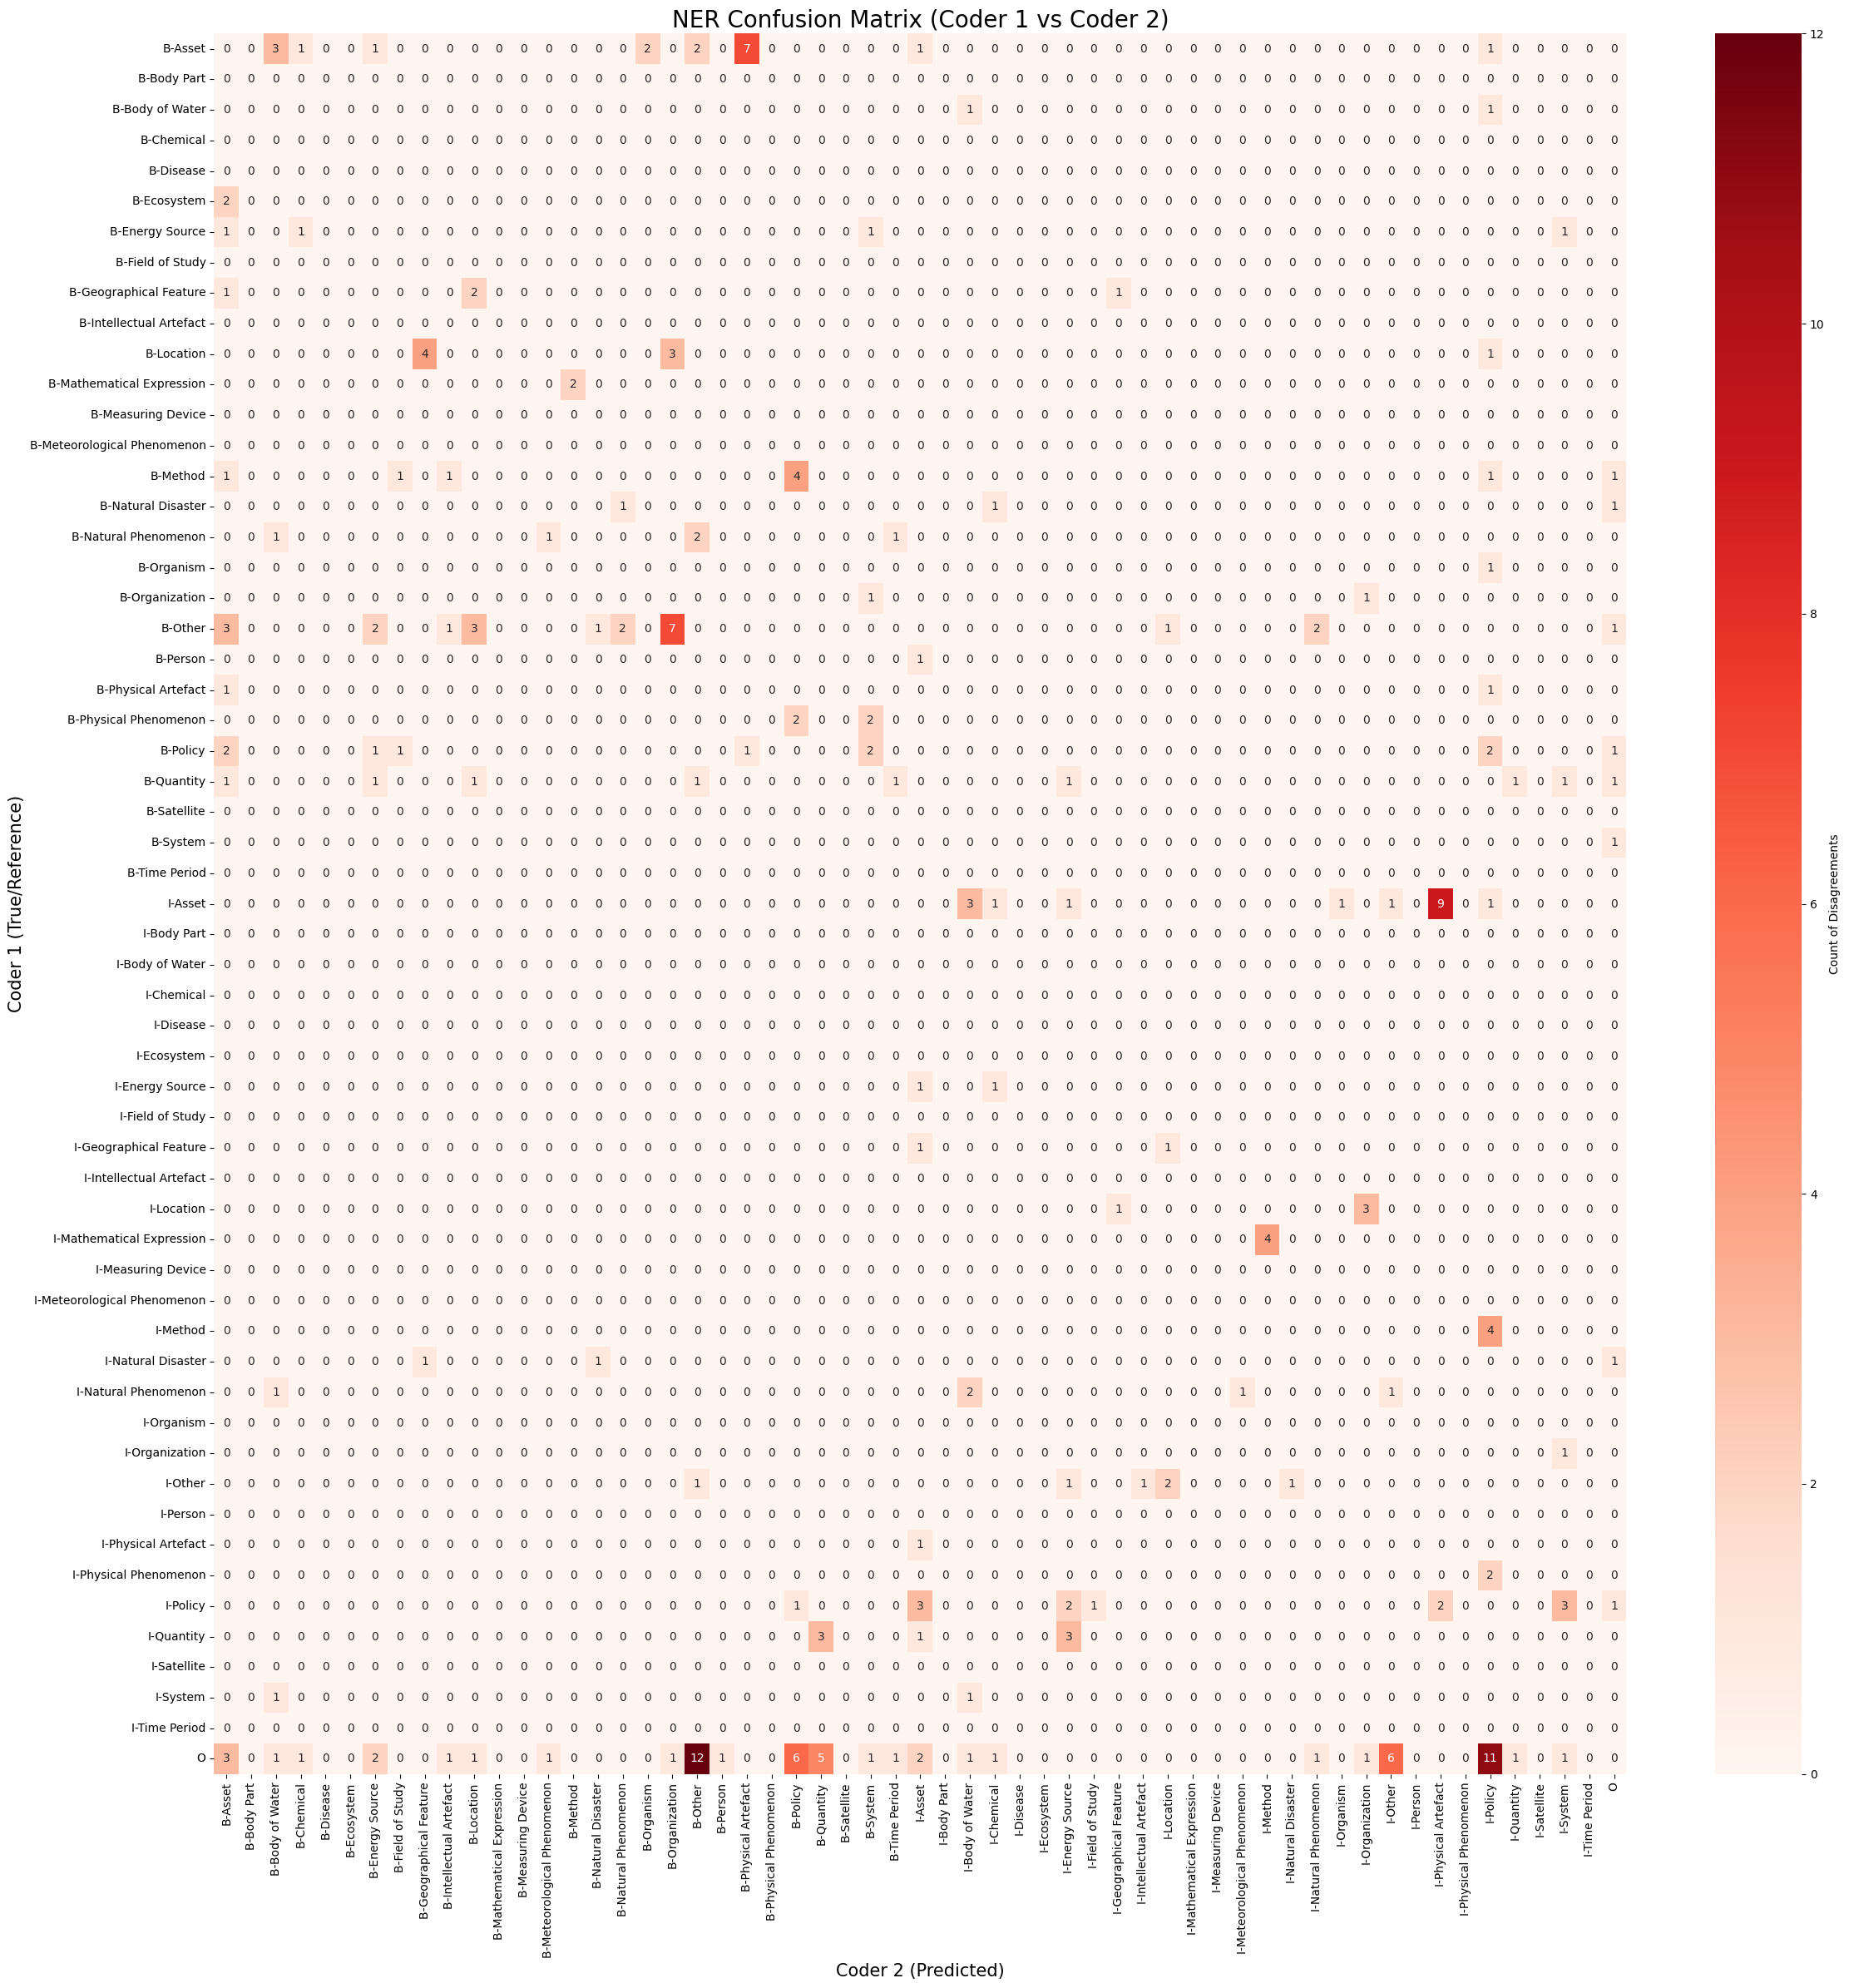

In [5]:
# 1. Run calculation
alpha, count, cm, mapping = calculate_ner_agreement(data_1, data_2)

# 2. Print results
print(f"Alpha: {alpha:.4f}")
print(f"Mapping size: {len(mapping)} tags")

# 3. Plot (using the plot function provided previously)
if cm is not None:
    plot_ner_confusion_matrix(cm, mapping, hide_diagonal=True)

In [6]:
print_top_confusions(cm, mapping)

Count      | Coder 1 (Row)                  -> Coder 2 (Col)                 
---------------------------------------------------------------------------
12         | O                              -> B-Other                       
11         | O                              -> I-Policy                      
9          | I-Asset                        -> I-Physical Artefact           
7          | B-Asset                        -> B-Physical Artefact           
7          | B-Other                        -> B-Organization                
6          | O                              -> B-Policy                      
6          | O                              -> I-Other                       
5          | O                              -> B-Quantity                    
4          | B-Location                     -> B-Geographical Feature        
4          | B-Method                       -> B-Policy                      
